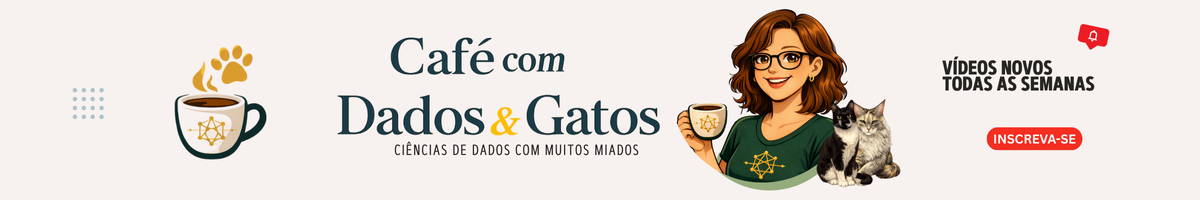

# **>>REDES NEURAIS**


---



<div style="
    font-family: Arial, sans-serif;
    max-width: 900px;
    margin: 0 auto;
    padding: 18px 20px;
    border-radius: 16px;
    border: 1px solid #e6e6e6;
    background: #ffffff;
    box-shadow: 0 6px 18px rgba(0,0,0,0.06);
">

  <div style="
      display:flex;
      align-items:center;
      justify-content:space-between;
      gap:12px;
      margin-bottom:12px;
  ">
    <h2 style="margin:0; font-size:22px; color:#222;">
      Redes Neurais — Visão Geral
    </h2>

  </div>

  <p style="margin:0 0 12px 0; color:#333; line-height:1.6;">
    Uma <b>Rede Neural</b> é um modelo de <b>Machine Learning</b> formado por várias unidades chamadas
    <b>neurônios artificiais</b>.
  </p>

  <div style="
      padding:14px 14px;
      border-radius:14px;
      background:#f8fafc;
      border:1px solid #eef2f7;
      margin-bottom:14px;
  ">
    <p style="margin:0; color:#333; line-height:1.6;">
      O nome técnico mais clássico para um neurônio artificial é o <b>Perceptron</b> —
      um modelo matemático criado por <b>Frank Rosenblatt (1958)</b>, inspirado no funcionamento dos neurônios biológicos.
    </p>
    <p style="margin:10px 0 0 0; color:#333; line-height:1.6;">
      Em redes neurais modernas, também é comum chamar essas unidades de <b>unidade de processamento</b>
      ou simplesmente <b>nó</b> (<i>node</i>).
    </p>
  </div>

  <h3 style="margin:0 0 8px 0; font-size:18px; color:#222;">
    🔹 O que um neurônio artificial faz na prática?
  </h3>

  <ol style="margin:0 0 14px 18px; color:#333; line-height:1.8;">
    <li>Recebe entradas (<i>inputs</i>)</li>
    <li>Aplica pesos (<i>weights</i>) em cada entrada</li>
    <li>Faz a soma ponderada dessas entradas</li>
    <li>Aplica uma função de ativação</li>
    <li>Gera uma saída (<i>output</i>) — normalmente um valor numérico que será passado para a próxima camada</li>
  </ol>

  <div style="
      padding:12px 14px;
      border-left:6px solid #ffcc00;
      border-radius:12px;
      background:#fff8e1;
      margin-bottom:14px;
      color:#333;
      line-height:1.6;
  ">
    <b>📌 Importante:</b> a saída de um neurônio geralmente é um <b>valor</b> (escalar).<br/>
    Quando temos vários neurônios em uma camada, o conjunto de saídas forma um <b>vetor</b>.<br/>
    As <b>matrizes</b> aparecem principalmente nos <b>pesos</b> e nas operações entre camadas.
  </div>

  <h3 style="margin:0 0 8px 0; font-size:18px; color:#222;">
    Redes neurais são neurônios organizados em camadas
  </h3>

  <ul style="margin:0 0 14px 18px; color:#333; line-height:1.8;">
    <li>✅ <b>Camada de entrada</b> (<i>Input Layer</i>): recebe os dados</li>
    <li>✅ <b>Camadas escondidas</b> (<i>Hidden Layers</i>): aprendem padrões e relações</li>
    <li>✅ <b>Camada de saída</b> (<i>Output Layer</i>): entrega a previsão final</li>
  </ul>

  <h3 style="margin:0 0 8px 0; font-size:18px; color:#222;">
    Como uma rede neural aprende?
  </h3>

  <ol style="margin:0 0 14px 18px; color:#333; line-height:1.8;">
    <li>A rede faz uma previsão</li>
    <li>Calcula o erro (diferença entre previsão e valor real)</li>
    <li>Ajusta os pesos para errar menos na próxima tentativa</li>
  </ol>

  <div style="
      padding:14px 14px;
      border-radius:14px;
      background:#f0fff4;
      border:1px solid #d7f5df;
      color:#1f4d2e;
      line-height:1.6;
  ">
    ✅ Uma rede neural <b>não decora</b> regras prontas.<br/>
    ✅ Ela <b>aprende padrões</b> a partir dos dados, melhorando aos poucos.
  </div>

</div>



## **EXEMPLO DE APRENDIZADO REDE NEURAL**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [ ]:
# Dataset 2D para classificação binária - sintético para fim didático
n = 300

x0 = torch.randn(n, 2) * 0.7 + torch.tensor([-2.0, -2.0])
x1 = torch.randn(n, 2) * 0.7 + torch.tensor([ 2.0,  2.0])

X = torch.cat([x0, x1], dim=0)
y = torch.cat([torch.zeros(n), torch.ones(n)]).view(-1, 1)

# Embaralha
idx = torch.randperm(X.shape[0])
X, y = X[idx], y[idx]

print(X.shape, y.shape)


torch.Size([600, 2]) torch.Size([600, 1])


In [ ]:
# Modelo de uma rede neural de verdade
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)


In [ ]:
# Treino real (Epoch → Loss descendo)
epochs = 30
losses = []

for epoch in range(1, epochs + 1):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch in [1, 5, 10, 20, 30]:
        print(f"Epoch {epoch:02d} → Loss = {loss.item():.4f}")


Epoch 01 → Loss = 0.6454
Epoch 05 → Loss = 0.4522
Epoch 10 → Loss = 0.3120
Epoch 20 → Loss = 0.1763
Epoch 30 → Loss = 0.1160


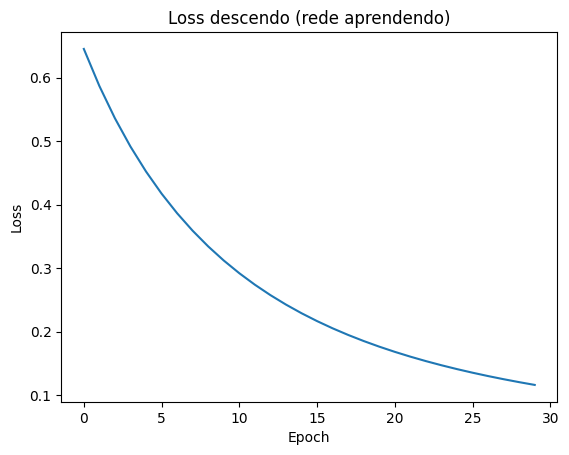

In [ ]:
# Plot da loss
plt.figure()
plt.plot(losses)
plt.title("Loss descendo (rede aprendendo)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
# Acurácia Final
with torch.no_grad():
    preds = (model(X) > 0.5).float()
    acc = (preds == y).float().mean().item()

print(f"Acurácia final: {acc*100:.2f}%")


Acurácia final: 100.00%




---



<div style="
    font-family: Arial, sans-serif;
    max-width: 900px;
    margin: 0 auto;
    padding: 18px 20px;
    border-radius: 16px;
    border: 1px solid #e6e6e6;
    background: #ffffff;
    box-shadow: 0 6px 18px rgba(0,0,0,0.06);
">

  <div style="
      display:flex;
      align-items:center;
      justify-content:space-between;
      gap:12px;
      margin-bottom:12px;
  ">
    <h2 style="margin:0; font-size:22px; color:#222;">
      Função de Ativação + PyTorch
    </h2>

  </div>

  <h3 style="margin:0 0 8px 0; font-size:18px; color:#222;">
    O que é função de ativação?
  </h3>

  <p style="margin:0 0 10px 0; color:#333; line-height:1.6;">
    Função de ativação é a etapa que decide <b>o que passa para a próxima camada</b> em uma rede neural.
    Ela pega o valor calculado por um neurônio e aplica uma transformação — isso dá <b>não-linearidade</b> para o modelo.
  </p>

  <div style="
      padding:12px 14px;
      border-left:6px solid #ff6b6b;
      border-radius:12px;
      background:#fff2f2;
      margin-bottom:14px;
      color:#333;
      line-height:1.6;
  ">
    <b>Sem função de ativação</b>, a rede vira uma sequência de operações lineares e fica limitada —
    ou seja, <b>não aprende padrões complexos</b>.
  </div>

  <p style="margin:0 0 8px 0; color:#333; line-height:1.6;">
    Nesta sequência, vamos ver as ativações mais usadas na prática:
  </p>

  <ul style="margin:0 0 14px 18px; color:#333; line-height:1.8;">
    <li><b>ReLU</b></li>
    <li><b>Sigmoid</b></li>
    <li><b>Tanh</b></li>
    <li><b>Leaky ReLU</b></li>
    <li><b>Softmax</b></li>
  </ul>

  <div style="
      padding:12px 14px;
      border-radius:14px;
      background:#f8fafc;
      border:1px solid #eef2f7;
      margin-bottom:16px;
      color:#333;
      line-height:1.6;
  ">
    Cada ativação tem um objetivo:
    algumas são melhores para <b>camadas internas</b>, e outras são usadas principalmente na <b>camada de saída</b>.
  </div>

  <h3 style="margin:0 0 8px 0; font-size:18px; color:#222;">
    O que é PyTorch?
  </h3>

  <p style="margin:0 0 12px 0; color:#333; line-height:1.6;">
    <b>PyTorch</b> é uma biblioteca de <b>Deep Learning</b> muito usada para criar e treinar redes neurais.
  </p>

  <ul style="margin:0 0 14px 18px; color:#333; line-height:1.8;">
    <li>✅ é simples de escrever código</li>
    <li>✅ é flexível (parece Python “de verdade”)</li>
    <li>✅ é muito usada em pesquisa e também em projetos reais</li>
    <li>✅ facilita testar ideias rápido</li>
  </ul>

  <div style="
      padding:14px 14px;
      border-radius:14px;
      background:#f0fff4;
      border:1px solid #d7f5df;
      color:#1f4d2e;
      line-height:1.6;
  ">
    Aqui a gente vai usar o <b>PyTorch</b> para aplicar as funções de ativação
    e ver o efeito <b>direto na saída</b>.
  </div>

</div>


# **Vamos para o código (PyTorch na prática)**

---



In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
import torch
import torch.nn as nn

print("Torch version:", torch.__version__)


Torch version: 2.9.0+cpu


**##  ReLU (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

relu = nn.ReLU()

entrada = torch.tensor([-3.0, -1.0, 0.0, 2.0, 5.0])
saida = relu(entrada)

print(saida)


tensor([0., 0., 0., 2., 5.])


## **Sigmoid (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

sigmoid = nn.Sigmoid()

entrada = torch.tensor([-3.0, -1.0, 0.0, 2.0, 5.0])
saida = sigmoid(entrada)

classe = (saida >= 0.5).int()

print("entrada:", entrada)
print("saida (0..1):", saida)
print("classe:", classe)


entrada: tensor([-3., -1.,  0.,  2.,  5.])
saida (0..1): tensor([0.0474, 0.2689, 0.5000, 0.8808, 0.9933])
classe: tensor([0, 0, 1, 1, 1], dtype=torch.int32)


## **Tanh (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

tanh = nn.Tanh()

entrada = torch.tensor([-3.0, -1.0, 0.0, 2.0, 5.0])
saida = tanh(entrada)

print("entrada:", entrada)
print("tanh:", saida)


entrada: tensor([-3., -1.,  0.,  2.,  5.])
tanh: tensor([-0.9951, -0.7616,  0.0000,  0.9640,  0.9999])


## **Leaky ReLU (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

leaky_relu = nn.LeakyReLU(negative_slope=0.01)

entrada = torch.tensor([-3.0, -1.0, 0.0, 2.0, 5.0])
saida = leaky_relu(entrada)

print("entrada:", entrada)
print("leaky:", saida)



entrada: tensor([-3., -1.,  0.,  2.,  5.])
leaky: tensor([-0.0300, -0.0100,  0.0000,  2.0000,  5.0000])


## **Softmax (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

softmax = nn.Softmax(dim=0)

entrada = torch.tensor([1.0, 2.0, 3.0])  # scores
saida = softmax(entrada)

print("entrada:", entrada)
print(saida)
print(saida.sum())


entrada: tensor([1., 2., 3.])
tensor([0.0900, 0.2447, 0.6652])
tensor(1.)


## **Bônus: ML: Treino / Validação / Teste (tamanho ideal)**

In [ ]:
# Função para mostrar, em gráfico, a divisão dos dados em treino, validação e teste
import matplotlib.pyplot as plt

def plot_split_short(train, val, test, title="70/15/15"):
    fig, ax = plt.subplots(figsize=(6.2, 2.2))

    # barras
    ax.barh([0], [train], left=0)
    ax.barh([0], [val], left=train)
    ax.barh([0], [test], left=train+val)

    # textos dentro das barras
    ax.text(train/2, 0, f"Treino\n{train}%", ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(train + val/2, 0, f"Val\n{val}%", ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(train + val + test/2, 0, f"Teste\n{test}%", ha="center", va="center",
            fontsize=12, fontweight="bold")

    # título no topo
    ax.text(50, 0.62, title, ha="center", va="center",
            fontsize=13, fontweight="bold")



    # limpar
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.55, 0.85)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    plt.tight_layout()
    plt.show()



## **70/15/15**

Tamanhos:
Total do dataset: 150
Treino: 105
Validação: 22
Teste: 23


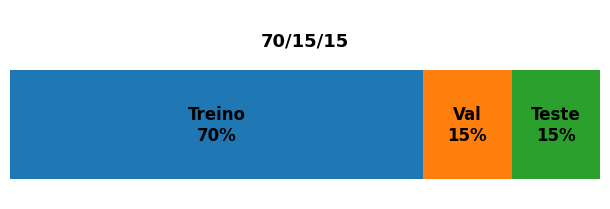

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Carregar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Primeiro: separar treino (70%) e resto (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Depois: dividir o "resto" em validação (15%) e teste (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Tamanhos:")
print("Total do dataset:", X.shape[0])
print("Treino:", X_train.shape[0])
print("Validação:", X_val.shape[0])
print("Teste:", X_test.shape[0])
plot_split_short(70, 15, 15, "70/15/15")




In [ ]:
# Função para mostrar, em gráfico, onde ocorre o Cross-Validation
import matplotlib.pyplot as plt

def plot_train_test_cv_short(train=80, test=20):
    fig, ax = plt.subplots(figsize=(6.2, 2.2))  # um pouco mais alto

    # barras
    ax.barh([0], [train], left=0)
    ax.barh([0], [test], left=train)

    # textos dentro das barras (centro)
    ax.text(train/2, 0, f"Treino\n{train}%", ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(train + test/2, 0, f"Teste\n{test}%", ha="center", va="center",
            fontsize=12, fontweight="bold")

    # título bem separado (topo)
    ax.text(50, 0.62, "80/20 + Cross-Validation", ha="center", va="center",
            fontsize=13, fontweight="bold")

    # CV jogado pra dentro da barra azul (mais embaixo)
    ax.text(train/2, -0.22, "Cross-Validation\n(dentro do treino)", ha="center",
            va="center", fontsize=9)

    # limpar e dar espaço vertical
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.55, 0.85)   # espaço extra em cima e embaixo
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.tight_layout()
    plt.show()





## **80/20 com cross-validation**

Tamanhos:
Total do dataset: 150
Treino (usado no CV): 120
Teste (final): 30
Cada fold de validação (aprox): 24 amostras
Scores de validação (5-fold): [0.958 0.958 0.958 0.958 1.   ]
Média: 0.967
Score no teste: 0.967


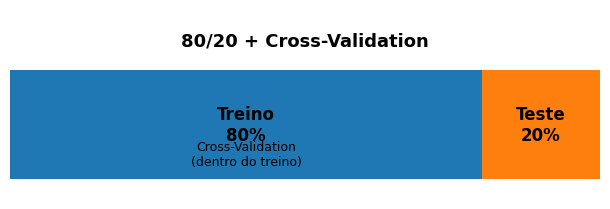

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

# Carregar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Modelo simples
model = LogisticRegression(max_iter=200)

# >>>>>>> Cross-validation (5-fold) no conjunto de treino
scores = cross_val_score(model, X_train, y_train, cv=5)

print("Tamanhos:")
print("Total do dataset:", X.shape[0])
print("Treino (usado no CV):", X_train.shape[0])
print("Teste (final):", X_test.shape[0])

# Fold
k = 5
print(f"Cada fold de validação (aprox): {X_train.shape[0]//k} amostras")

print("Scores de validação (5-fold):", scores.round(3))
print("Média:", round(scores.mean(), 3))

# Treinar no conjunto de treino inteiro
model.fit(X_train, y_train)

# Avaliar no conjunto de teste (final)
test_score = model.score(X_test, y_test)
print("Score no teste:", round(test_score, 3))

plot_train_test_cv_short()
